In [2]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import datetime as dt
#from mpl_toolkits.basemap import Basemap
import gsw
%matplotlib inline
import glob
import matplotlib.path as mpath
import matplotlib.ticker as mticker
import gsw
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import cartopy
import cartopy.feature as cfeature
import netCDF4 as nc
import cartopy.crs as ccrs
import ArcTools as Atools

In [2]:
# bathy
etopo = xr.open_dataset('/data0/data/REFERENCE_DATA/BATHYMETRY/DATA/ETOPO2v2c_f4.nc')
lon_bat = etopo.x.data
lat_bat = etopo.y.data
topo = etopo.z.data
loi_topo, lai_topo = np.meshgrid(lon_bat, lat_bat)

In [3]:
gsw.distance([0,3],[60,60])/1000
gsw.distance([0,8],[80,80])/1000
dlat = gsw.distance([0,1],[0,0])/1000
3#00/(dlat*np.cos(61.5*np.pi/180))

scf300 = []
scf150 = []
for lac in [61.5,64.5,67.5,70.5,73.5,76.5,79.5,82.5,86.5,88.5]:
    deg = 300/(dlat*np.cos(lac*np.pi/180))
    div = 360//deg
    res = 360%deg
    deg_new = (div*deg +res)/div
    scf300.append(deg_new)
    deg = 150/(dlat*np.cos(lac*np.pi/180))
    div = 360//deg
    res = 360%deg
    deg_new = (div*deg +res)/div
    scf150.append(deg_new)

In [4]:
import numpy as np
import csv

with open('Arctic_design_10m_150_test_new.csv', 'w', newline='') as csvfile:

    writer = csv.writer(csvfile, delimiter=',', quotechar='|',
                        quoting=csv.QUOTE_MINIMAL)

    writer.writerow([
        'Box ID',
        'Longitude 1',
        'Longitude 2',
        'Latitude 1',
        'Latitude 2',
        'Mean Topo'
    ])

    xc150_all = []
    yc150_all = []
    box_id = []
    mean_topo = []

    boxid = 1

    for i, lac in enumerate(np.arange(60, 90, 3)):

        dlon = scf150[i][0]

        x1 = -180
        y1 = lac
        y2 = lac + 3

        while x1 < 180 - 1e-8:

            # ensure last box closes at 180°
            x2 = min(x1 + dlon, 180)

            # ---- nearest grid points ----
            ila1 = np.argmin(np.abs(lat_bat - y1))
            ilo1 = np.argmin(np.abs(lon_bat - x1))

            ila2 = np.argmin(np.abs(lat_bat - y2))
            ilo2 = np.argmin(np.abs(lon_bat - x2))

            ila3 = np.argmin(np.abs(lat_bat - y1))
            ilo3 = np.argmin(np.abs(lon_bat - x2))

            ila4 = np.argmin(np.abs(lat_bat - y2))
            ilo4 = np.argmin(np.abs(lon_bat - x1))

            # ---- depth conditions ----
            cond1 = topo[ila1, ilo1] > -10
            cond2 = topo[ila2, ilo2] > -10
            cond3 = topo[ila3, ilo3] > -10
            cond4 = topo[ila4, ilo4] > -10

            cond = cond1 and cond2 and cond3 and cond4

            if not cond:

                mt = np.nanmean([
                    topo[ila1, ilo1],
                    topo[ila2, ilo2],
                    topo[ila3, ilo3],
                    topo[ila4, ilo4]
                ])

                box_id.append(boxid)
                mean_topo.append(mt)

                xc150_all.append([x1, x2, x2, x1, x1])
                yc150_all.append([y1, y1, y2, y2, y1])

                writer.writerow([
                    boxid,
                    round(x1, 1),
                    round(x2, 1),
                    round(y1, 1),
                    round(y2, 1),
                    round(mt, 1)
                ])

                boxid += 1

            # move to next longitude box
            x1 = x2

In [5]:
import pandas as pd
import numpy as np

boxes = pd.read_csv('/home/aprigent/Documents/Projects/Analysis_obs/Arctic_design_10m_150_test_new.csv')



xc150 = np.array(([boxes["Longitude 1"].values,boxes["Longitude 2"].values,
                   boxes["Longitude 2"].values,boxes["Longitude 1"].values,boxes["Longitude 1"].values])).T
yc150 = np.array(([boxes["Latitude 1"].values,boxes["Latitude 1"].values,
                   boxes["Latitude 2"].values,boxes["Latitude 2"].values,boxes["Latitude 1"].values])).T
box_id = np.array(boxes["Box ID"].values)

In [8]:
topo_low_res = topo[::10,::10]
loi_topo_low_res = loi_topo[::10,::10]
lai_topo_low_res = lai_topo[::10,::10]


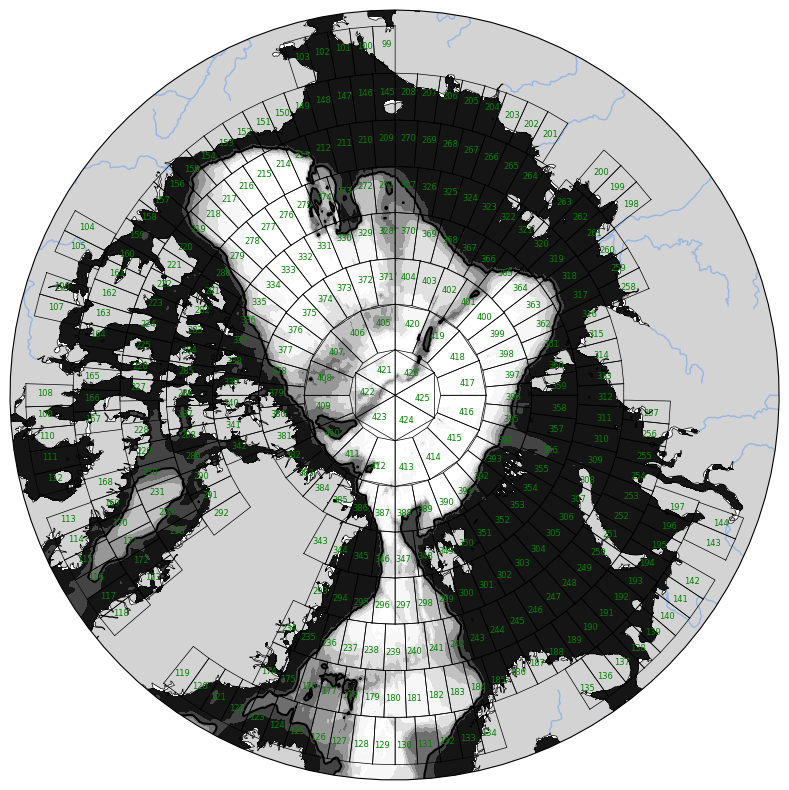

In [16]:
f,ax = plt.subplots(1,1,figsize=[10,10],subplot_kw={'projection':  ccrs.NorthPolarStereo()})
ftz=15

levels=np.arange(0,4000,500)
Atools.plot_arctic_ax_map_new(ax,gridlines=False)

ax.contourf(loi_topo_low_res,
               lai_topo_low_res,
               -topo_low_res,levels=levels,cmap="Greys_r",transform=ccrs.PlateCarree())

cs=ax.contour(loi_topo_low_res,
               lai_topo_low_res,
               -topo_low_res,[1000],colors='black',transform=ccrs.PlateCarree())#,cmap='ocean')


for i in range(len(xc150)):
    if np.all(yc150[i] >= 65):
        ax.plot(xc150[i],yc150[i],'k',linewidth=.5, transform=ccrs.PlateCarree())
        ax.text(np.mean(xc150[i]),np.mean(yc150[i]),box_id[i], fontsize=6, color='g',transform=ccrs.PlateCarree(),va='center',ha='center')